# Classificazione di tumori benigni e maligni

**Cardillo Antonino - Ragazzini Manuel**


# 1. Introduzione del problema e Presentazione del Dataset

- **Il problema affrontato:** L'obiettivo principale di questo studio è addestrare e confrontare diversi modelli di apprendimento automatico per l'identificazione precoce e accurata dei tumori al seno, effettuando una classificazione tra masse benigne e maligne.

- **I task che seguiremo nel progetto:**
    1. Descrizione e analisi iniziale del dataset.
    2. Pulizia dei dati (rimozione di informazioni amministrative o nulle).
    3. Analisi Esplorativa dei Dati (EDA) tramite calcolo delle statistiche descrittive e visualizzazione grafica.
    4. Outlier Detection (rilevamento dei valori anomali).
    5. Preprocessing finale e bilanciamento dei dati (Train/Test Split e Standardizzazione).
    6. Classificazione Supervisionata tramite il confronto di quattro differenti algoritmi (Modelli Lineari, Geometrici, Ensemble e Reti Neurali).

- **L'obiettivo del progetto:** Vogliamo dimostrare numericamente e graficamente che le cellule maligne presentano caratteristiche morfologiche (come dimensione, accrescimento ed irregolarità dei contorni) nettamente superiori e più caotiche rispetto a quelle benigne, sfruttando questa separazione per massimizzare la precisione diagnostica in entrambi i casi.

- **L'interesse pratico e applicativo:** In ambito oncologico, l'utilità di questo sistema risiede nella capacità di supportare il personale medico fornendo una diagnosi altamente affidabile. Dal punto di vista delle metriche, l'interesse principale è massimizzare la sensibilità (Recall) per ridurre al minimo i **falsi negativi**: mandare a casa una paziente malata con una diagnosi erroneamente sana rappresenta il rischio più grave in assoluto. Di riflesso, si cercherà di mantenere alta la precisione per limitare i falsi positivi, evitando stress psicologici e interventi non necessari su pazienti sane.


# 2. Descrizione del dataset

Il dataset è stato recuperato al seguente link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

Ogni riga del dataset rappresenta una paziente sottoposta a una biopsia al seno. Il campione prelevato è stato digitalizzato e analizzato per estrarre una serie di caratteristiche geometriche delle cellule, successivamente convertite in valori numerici. Tra le principali caratteristiche misurate troviamo la dimensione, la linearità del perimetro, la simmetria, la regolarità della superficie e la dimensione frattale.
Il dataset è composto da 569 righe e 33 colonne, comprendenti l'identificativo della paziente (id) e una colonna vuota, che verrà rimossa durante il pre-processing. Per ciascuna caratteristica sono riportate tre misure: la media (_mean), l'errore standard (_se) e la media dei tre valori più elevati (_worst).

La variabile target è diagnosis, che indica l'esito della diagnosi e può assumere due valori: M(aligno) oppure B(enigno). Di conseguenza, il problema di Machine Learning è una classificazione binaria.
    

# 3. Lettura e preparazione dei dati

Importazione delle librerie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats


Importiamo il dataset

In [2]:
file_path = "cancer.csv"
df = pd.read_csv(file_path)

Visualizziamo le prime righe del dataset

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Controlliamo le dimensioni del dataset

In [4]:
df.shape

(569, 33)

Estraiamo i nomi delle colonne e il tipo

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Notiamo che la colonna diagnosis ha come tipo object in quanto i valori che ritroveremo sono non di tipo numerico ma il carattere M ed il carattere B, in sguito saranno convertiti rispettivamente in 1 e 0 

Prima di proseguire facciamo un ulteriore controllo sul contenuto nullo di ogni colonna anche se dallo shape già abbiamo ricavato il valore non-null count. Un valore nullo negli algoritmi tipo Logistic Regression bloccano o danno errori.

In [6]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In entrambi i casi troviamo una colonna con etichetta 'Unnamed: 32' che non contiene dati, in realtà è una colonna vuota e che pandas le assegna quella etichetta. A questo punto la eliminiamo e cogliamo l'occasione per eliminare anche la colonna 'id' in quanto ci riporta solo dei valori sequenziali, il riferimento al paziente, che non utilizziamo nella nostra analisi. 

In [7]:
df=df.drop(columns=['id','Unnamed: 32'], errors='ignore')
#df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

# 4. Visualizzazione ed EDA
Abbiamo ripulito il dataset, ora controlliamo di quanto è sbilanciato, nel caso sia troppo sbilanciato, i modelli che alleneremo tenderanno a predire la diagnosi che ha la percentuale più alta e maggiormente sbilanciata. Procediamo facendo un conteggio delle occorrenze del valore M e del valore B della colonna diagnosis e poi calcoliamo la percentuale. 

Conteggio:

In [8]:
conteggio = df['diagnosis'].value_counts()
conteggio

diagnosis
B    357
M    212
Name: count, dtype: int64

Percentuale:

In [9]:
percentuale=df['diagnosis'].value_counts(normalize=True)*100
percentuale

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

Sia nel conteggio che nella rappresentazione in percentuale, il dataset risulta avere un moderato sbilanciamento 63% e 37%.

Visualizziamo dal punto di vista statistico il dataset

In [10]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Il dataset è composto da 30 caratteristiche, queste si suddividono in tre macro sezioni che sono le medie, gli errori standard e la media dei tre valori più grandi.
Si decide volutamente di utilizzare le metriche medie (`_mean`) in questa fase iniziale per ottenere una panoramica sul comportamento statistico generale del campione, rimandando l'analisi delle metriche d'errore (`_se`) e di picco (`_worst`) alla successiva fase di modellazione predittiva.
Per non avere ridondanza di dati e a colpo d'occhio evidenziare le differenze, possiamo selezionare una caratteristica geometrica per ognuna di queste tre sezioni: 
1. **Dimensione:** (area_mean) come indicatore della volumetria cellulare.
2. **Forma/Rugosità:** (texture_mean) come indicatore delle proprietà di superficie e rifrazione del nucleo.
3. **Irregolarità dei contorni:** (concavity_mean) come indicatore del livello di deformazione dei contorni.


Vediamo prima dal punto di vista numerico la relazione tra queste caratteristiche, raggruppiamo le medie per ogni classe/famiglia, le stampiamo a video, dopo le rappresenteremo graficamente con i boxplot.

In [11]:
medie_per_classe = df.groupby('diagnosis').mean()
colonne_chiave = ['area_mean', 'texture_mean', 'concavity_mean']

print("--- CONFRONTO DELLE MEDIE CLINICHE ---")
print(medie_per_classe[colonne_chiave])

--- CONFRONTO DELLE MEDIE CLINICHE ---
            area_mean  texture_mean  concavity_mean
diagnosis                                          
B          462.790196     17.914762        0.046058
M          978.376415     21.604906        0.160775


Notiamo che la media delle aree dei maligni è quasi il doppio dei benigni, questo ci fa capire che è una delle caratteristiche giusta per il confronto, la concavità anche quella ha una differenza abbastanza forte considerando 0 = perfettamente convesso, 1 = massima concavità.

Di seguito graficamente con dei boxplot rappresentiamo le tre colonne delle caratteristiche scelte. Sull'asse delle X le diagnosi e sull'asse delle Y le caratteristiche. 

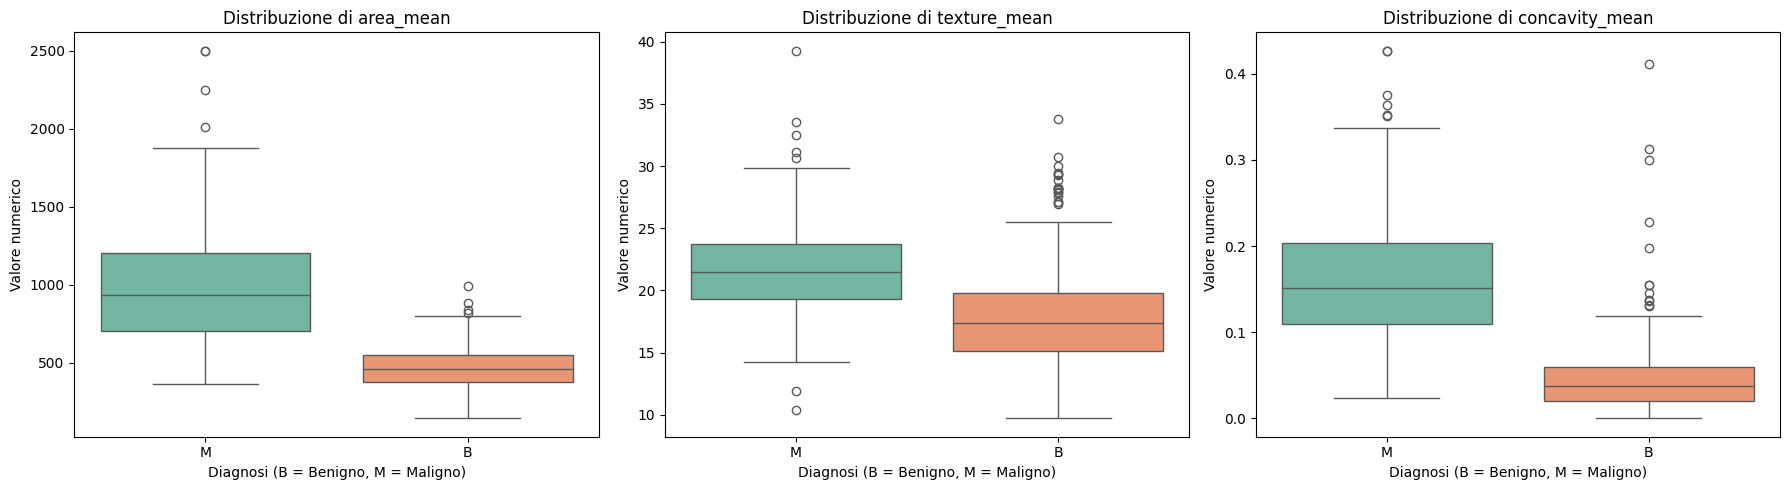

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rappresentanti = ['area_mean', 'texture_mean', 'concavity_mean']

for i, feature in enumerate(rappresentanti):
    sns.boxplot(ax=axes[i], x='diagnosis', y=feature, data=df, hue='diagnosis', palette='Set2', legend=False)
    axes[i].set_title(f'Distribuzione di {feature}')
    axes[i].set_xlabel('Diagnosi (B = Benigno, M = Maligno)')
    axes[i].set_ylabel('Valore numerico')

plt.tight_layout()
plt.show()

Dal grafico si evidenzia che per la media dell'area i Maligni sono più grandi, hanno valori che vanno da circa 750 a 1200 mentre i Benigni hanno dimensioni che vanno da circa 250 a 750. Stessa cosa la notiamo per la caratteristica della concavità. Analizzando ancora il grafico si vede che nei BoxPlot area_mean e concavity_mean si vede da subito una netta distinsione tra i Maligni e i Benigni, mentre texture_mean in parte si sovrappongono. La netta differenza nei boxplot indica che le classi sono ben separabili, per questo la Regressione Logistica è una scelta adatta: è un modello lineare che trasforma le caratteristiche in una probabilità tra 0 e 1.. Altra cosa da notare e da non sottovalutare è che le scale di ogni cartteristica è diversa, dovremo effettuare uno scaling. Infine possiamo vedere anche che sono presenti degli outlier rappresentati dai cerchietti oltre i baffi del grafico.  

Eventuali correlazioni

Per evidenziare eventuali correlazioni tra le caratteristiche usiamo il metodo corr() di pandas. Prima selezioniamo di nuovo i nostri 3 rappresentanti delle famiglie per vedere come correlano tra loro

In [13]:

rappresentanti = ['area_mean', 'texture_mean', 'concavity_mean']

tabella_correlazione = df[rappresentanti].corr()

print("--- MATRICE DI CORRELAZIONE NUMERICA ---")
print(tabella_correlazione)

--- MATRICE DI CORRELAZIONE NUMERICA ---
                area_mean  texture_mean  concavity_mean
area_mean        1.000000      0.321086        0.685983
texture_mean     0.321086      1.000000        0.302418
concavity_mean   0.685983      0.302418        1.000000


Osserviamo la Matrice di Correlazione Numerica

Gli indici di correlazione di Pearson, che vanno da -1 a +1 ,estratti sui tre rappresentanti delle famiglie di caratteristiche, vediamo che tra area e concavità c'è una forte relazione, che al crescere dell'area cresce anche la concavità, ci avviciniamo molto al valore 1 mentre la relazione tra la texture ed entrambe le altre due caratteristiche è molto più bassa, questo ci fa capire che è indipendente dalle altre. 

# 5. Outlier detection / preprocessing
    
Preparazione dei dati per i modelli.

Come primo passo trasformiamo il target Diagnosis che ha come  valori attuali 'M' e 'B' in numerico (1 e 0)".

In [14]:
mappa_diagnosi = {'M': 1, 'B': 0}
df['diagnosis'] = df['diagnosis'].replace(mappa_diagnosi).infer_objects(copy=False)
df['diagnosis'].head()

C:\Users\antonino.cardillo\AppData\Local\Temp\ipykernel_14320\1761074491.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'] = df['diagnosis'].replace(mappa_diagnosi).infer_objects(copy=False)


0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

## Identifichiamo gli Outlier
Per identificare e isolare gli outlier useremo lo Z-Score Standard, che si basa sulla media e deviazione standard, sulle nostre feature per identificare quali righe superano la soglia critica di 3 deviazioni standard dalla media, questo valore normalmente viene considerato statisticamente un'anomalia estrema.



Escludiamo la colonna target diagnosis che non ci viene utile
nel calcolo dello Z-Score.
Il calcolo lo faremo sul'intero dataset e non solo su determinate caratteristiche.

In [15]:
feature_cols = [col for col in df.columns if col != 'diagnosis']

CAlcoliamo lo z-score

In [16]:
z_scores = np.abs(stats.zscore(df[feature_cols]))

Evidenziamo quale caratteristica ha il valore superiore o inferiore a 3 deviazioni standard e quindi quali pazienti.

In [17]:
righe_outlier = np.where(z_scores > 3)[0]

Potrebbe essere che una paziente abbia non una sola caratteristica che identificata come outlier ma più di una quindi per non avere più volte la stessa paziente andiamo a prenderla una sola volta usando unique

In [18]:
righe_outlier_uniche = np.unique(righe_outlier)



Stampiamo i risultati

In [19]:
print(f"Numero di pazienti totali nel dataset: {df.shape[0]}")
print(f"Numero di pazienti identificati come outlier : {len(righe_outlier_uniche)}")

Numero di pazienti totali nel dataset: 569
Numero di pazienti identificati come outlier : 74


L'analisi tramite **Z-Score Standard** ha individuato 74 record considerati outlier, pari a circa il 13% del dataset. Dopo aver analizzato questi risultati, si è deciso di **mantenere tutti i valori**, senza eliminarli (*dropping*) né modificarli (*clipping*).

La scelta è stata fatta per i seguenti motivi:

1. Gli outlier rappresentano casi reali e nel contesto della diagnosi del tumore al seno, valori molto elevati di alcune caratteristiche delle cellule non sono necessariamente errori o anomalie dovute alla raccolta dei dati. Al contrario, possono rappresentare casi clinici realmente più gravi e quindi contenere informazioni importanti per distinguere tumori benigni e maligni.

2. Rimuovere circa il 13% dei dati significherebbe perdere proprio gli esempi più rappresentativi dei casi maligni. Questo potrebbe rendere più difficile per gli algoritmi riconoscere tali situazioni e aumentare il numero di falsi negativi, cioè tumori maligni classificati erroneamente come benigni.

3. Alcuni algoritmi sono sensibili alla presenza di valori estremi, ma questo problema sarà gestito nella fase di pre-processing applicando lo **StandardScaler**, che porta tutte le variabili sulla stessa scala senza eliminare le informazioni contenute negli outlier.

Per questi motivi si è ritenuto più opportuno conservare tutti i record del dataset, mantenendo intatta l'informazione originale e consentendo ai modelli di apprendere anche dai casi clinicamente più significativi.



# 6. Implementazione di uno o più modelli
Implementazione di uno o più modelli

In questa sezione andiamo ad addestrare e confrontare quattro differenti architetture di Machine Learning analizzate durante il corso, coprendo modelli lineari, geometrici, probabilistici e connessionisti:
* Logistic Regression (Modello Lineare):
 Scelta perché l'EDA ha mostrato una buona separabilità geometrica delle classi nei boxplot.
* Support Vector Machines - SVM (Modello Geometrico):
 Ottimo per massimizzare il margine di separazione tra Benigni e Maligni in spazi multidimensionali.
* Random Forest (Modello basato su Alberi):
 Scelto perché non risente della multicollinearità tra raggio/area/perimetro che sono per forza di cose correlati fortemente tra loro ed è **robusto in presenza di outlier**.
* Multi-Layer Perceptron - MLP (Rete Neurale Artificiale):
Scelta per catturare eventuali relazioni non lineari complesse tra le caratteristiche geometriche delle cellule.


Prima di addestrare i modelli, il dataset viene suddiviso in due parti: un Train Set (80%), utilizzato per l'apprendimento degli algoritmi, e un Test Set (20%), impiegato esclusivamente per valutare le prestazioni del modello su dati mai visti in precedenza.

Per garantire una valutazione corretta e affidabile vengono adottati due accorgimenti.

Suddivisione stratificata (stratify=y). Il dataset non è perfettamente bilanciato, poiché contiene circa il 63% di casi benigni e il 37% di casi maligni. Utilizzando la stratificazione, entrambe le suddivisioni mantengono la stessa proporzione delle due classi, rendendo il confronto tra fase di addestramento e fase di test più rappresentativo.

Prevenire il Data Leakage. Prima dell'addestramento viene applicato lo StandardScaler per standardizzare le variabili. Per evitare che il modello utilizzi informazioni provenienti dal Test Set durante l'apprendimento, lo scaler viene addestrato (fit) solo sui dati del Train Set. Gli stessi parametri ottenuti vengono poi utilizzati per trasformare sia il Train Set sia il Test Set (transform). In questo modo il Test Set rimane completamente indipendente e rappresenta una verifica imparziale delle prestazioni del modello.

Questa procedura permette di ottenere una valutazione più realistica delle capacità di generalizzazione degli algoritmi e riduce il rischio di ottenere risultati artificialmente ottimistici.

Come prima cosa separiamo Caratteristiche (X) dal Target (y)

In [20]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

Effettuiamo lo split Train/Test (80% / 20%) con stratificazione

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Inizializziamo lo StandardScaler

In [22]:
scaler = StandardScaler()

Scaliamo le caratteristiche in modo differenziato per evitare il Data Leakage

In [23]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Verifichiamo

In [24]:
print("--- VERIFICA FINALE DELLE DIMENSIONI ---")
print(f"Pazienti nel Train Set (X_train_scaled): {X_train_scaled.shape[0]}")
print(f"Pazienti nel Test Set (X_test_scaled): {X_test_scaled.shape[0]}")
print(f"Numero di feature in input per ogni paziente: {X_train_scaled.shape[1]}")

--- VERIFICA FINALE DELLE DIMENSIONI ---
Pazienti nel Train Set (X_train_scaled): 455
Pazienti nel Test Set (X_test_scaled): 114
Numero di feature in input per ogni paziente: 30


## Importiamo le librerie comuni agli algoritmi

In [25]:
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

## Primo modello: Logistic Regression

Importiamo le librerie del modello e le metriche

In [26]:
from sklearn.linear_model import LogisticRegression


Per la ricerca dei migliori iperparametri utilizziamo la GridSearchCV

In [27]:
param_grid_lr = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2']
}

Configuriamo la GridSearch impostando la RECALL come obiettivo principale

In [28]:
grid_lr = GridSearchCV(
    estimator=LogisticRegression(solver='liblinear',max_iter=1000, random_state=42), 
    param_grid=param_grid_lr, 
    scoring='recall', 
    cv=5,
    n_jobs=-1
)

Avviamo l'addestramento e la ricerca automatica

In [29]:
grid_lr.fit(X_train_scaled, y_train)

C:\Users\antonino.cardillo\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\antonino.cardillo\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...r='liblinear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold

Stampiamo i risultati ottimizzati

In [30]:
print("--- RISULTATI OTTIMIZZAZIONE LOGISTIC REGRESSION ---")
print(f"Miglior parametri scelti dalla griglia: {grid_lr.best_params_}\n")

--- RISULTATI OTTIMIZZAZIONE LOGISTIC REGRESSION ---
Miglior parametri scelti dalla griglia: {'C': 0.1, 'penalty': 'l1'}



Estraiamo il modello migliore per effettuare il test finale

In [31]:
best_lr_model = grid_lr.best_estimator_
y_pred_lr = best_lr_model.predict(X_test_scaled)

Stampiamo il Report di classificazione

In [32]:
print("--- PERFORMANCE LOGISTIC REGRESSION OTTIMIZZATA ---")
print(classification_report(y_test, y_pred_lr))

--- PERFORMANCE LOGISTIC REGRESSION OTTIMIZZATA ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Interpretiamo i coifficienti facendo un'estrazione e associandoli ai nomi delle colonne originali

In [33]:
pesi_features = pd.DataFrame({
    'Feature': X.columns,
    'Coefficiente (Peso)': best_lr_model.coef_[0]
})

Ordiniamo i pesi dal più influente al meno influente per la classe 1 (Maligno)

In [34]:
pesi_features = pesi_features.sort_values(by='Coefficiente (Peso)', ascending=False)

Stampiamo e confrontiamo sia le prime 5 che le ultime 5 con head() e tail()

In [35]:
print("--- PESI DELLE CARATTERISTICHE NELLA LOGISTIC REGRESSION ---")
print(pesi_features.head(5)) 
print("\n...")
print(pesi_features.tail(5))

--- PESI DELLE CARATTERISTICHE NELLA LOGISTIC REGRESSION ---
                 Feature  Coefficiente (Peso)
20          radius_worst             2.118948
7    concave points_mean             0.976743
21         texture_worst             0.695876
27  concave points_worst             0.444193
10             radius_se             0.301031

...
                    Feature  Coefficiente (Peso)
22          perimeter_worst                  0.0
25        compactness_worst                  0.0
23               area_worst                  0.0
26          concavity_worst                  0.0
29  fractal_dimension_worst                  0.0


L'estrazione dei coefficienti della Logistic Regression ci fa notare che le caratteristiche prese in esame nell'EDA sono riconducibili a quelle con maggior peso, il raggio è molto correlato all'area che abbiamo scelto, poi troviamo la texture e la concavity.

## Secondo modello: SVM (Support Vector Machine)
Questo modello, prova a individuare un iperpiano di separazione tra le classi, in modo da massimizzare il margine, cioè la distanza minima tra le classi. In particolare, il margine viene determinato anche dai vettori di supporto. Utilizzeremo la GridSearchCV per individuare i migliori iperparametri.

Importiamo la libreria di SVM e inizializziamo la GridSearchCV

Configuriamo la GridSearchCV per la ricerca del parametro C e il Kernel

In [36]:
from sklearn.svm import SVC
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

 Impostiamo la RECALL come obiettivo principale e la Cross-Validation impostata a 5

In [37]:
grid_svm = GridSearchCV(
    estimator=SVC(random_state=42), 
    param_grid=param_grid_svm, 
    scoring='recall', 
    cv=5,
    n_jobs=-1
)

Addestriamo e visualizziamo i migliori parametri scelti.

In [38]:
grid_svm.fit(X_train_scaled, y_train)

print("--- RISULTATI GRIDSEARCHCV SVM ---")
print(f"Migliori parametri scelti : {grid_svm.best_params_}\n")

--- RISULTATI GRIDSEARCHCV SVM ---
Migliori parametri scelti : {'C': 10, 'kernel': 'rbf'}



Valutiamo il modello vincitore sul Test Set

In [39]:
best_svm_model = grid_svm.best_estimator_
y_pred_svm = best_svm_model.predict(X_test_scaled)

print("--- PERFORMANCE SVM OTTIMIZZATA ---")
print(classification_report(y_test, y_pred_svm))

--- PERFORMANCE SVM OTTIMIZZATA ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## Terzo modello: Random Forest
Questo modello che andremo ad addestrare per valutarne le performance è la **Random Forest**. A differenza dei primi due, questo non è un modello lineare: si tratta di un algoritmo basato su alberi di decisione, più robusto in presenza di outlier e capace di gestire la forte correlazione tra le caratteristiche geometriche senza subire alterazione nei risultati.

Importiamo la libreria del modello RandomForest

In [40]:
from sklearn.ensemble import RandomForestClassifier


Utilizzeremo la ricerca degli iperparametri migliori con GridSearchCV per ottimizzare il modello.
Definiamo la griglia di parametri da testare

In [41]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],       # Numero di alberi nella foresta
    'max_depth': [None, 5, 10],            # Massima profondità degli alberi
    'criterion': ['gini', 'entropy']       # Metrica per misurare la qualità dello split
}

Inizializziamo GridSearchCV impostando la RECALL come obiettivo primario
cv=5 significa che farà una Cross-Validation a 5 pieghe per essere matematicamente sicuro del risultato

In [42]:
grid_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                       param_grid=param_grid_rf, 
                       scoring='recall', 
                       cv=5,
                       n_jobs=-1)

Avviamo la ricerca della combinazione migliore sul Train Set scalato

In [43]:
grid_rf.fit(X_train_scaled, y_train)

print("--- RISULTATI OTTIMIZZAZIONE RANDOM FOREST ---")
print(f"Migliori iperparametri trovati: {grid_rf.best_params_}\n")

--- RISULTATI OTTIMIZZAZIONE RANDOM FOREST ---
Migliori iperparametri trovati: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 50}



Estraiamo il modello migliore e facciamo le predizioni sul Test Set

In [44]:
best_rf_model = grid_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_scaled)

Stampiamo il report di classificazine

In [45]:
print("--- PERFORMANCE RANDOM FOREST OTTIMIZZATA (TEST SET) ---")
print(classification_report(y_test, y_pred_rf))

--- PERFORMANCE RANDOM FOREST OTTIMIZZATA (TEST SET) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



La ricerca automatica ha stabilito che la configurazione ideale per il nostro dataset prevede la generazione di 50 alberi (invece dei 100 standard) e l'utilizzo dell'indice di impurità di Gini (criterion: 'gini') come criterio matematico per effettuare i tagli e le decisioni nei singoli nodi.

Questo modello ottimizzato ha raggiunto gli stessi valori del SVM in Precision, Recall e F1-score entrambi NON hanno fatto meglio della Logistic Regression.

## Quarto ed ultimo modello: MLP (Multi-Layer Perceptrons)
Questo modello è una rete neurale multi layer.

Come per tutti i modelli importiamo la libreria e inizializziamo i parametri della GridSearchCV

In [46]:
from sklearn.neural_network import MLPClassifier

param_grid_mlp = {
    'hidden_layer_sizes': [(30,), (50,), (100,)],
    'activation': ['relu', 'tanh', 'logistic', 'identity']
}


grid_mlp = GridSearchCV(estimator=MLPClassifier(max_iter=1000, random_state=42),
                         param_grid=param_grid_mlp,
                         scoring='recall',
                         cv=5)

grid_mlp.fit(X_train_scaled, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu', 'tanh', ...], 'hidden_layer_sizes': [(30,), (50,), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

Stampiamo i parametri migliori scelti dall GridSearchCV

In [47]:
print("--- RISULTATI OTTIMIZZAZIONE MLP ---")
print(f"Migliori iperparametri trovati: {grid_mlp.best_params_}\n")

--- RISULTATI OTTIMIZZAZIONE MLP ---
Migliori iperparametri trovati: {'activation': 'relu', 'hidden_layer_sizes': (50,)}



Testiamo il modello

In [48]:
best_mlp_model = grid_mlp.best_estimator_
y_pred_mlp = best_mlp_model.predict(X_test_scaled) 

Per questo modello facciamo un ulteriore verifica, generiamo un grafico per visualizzare la Learning Curve e capire visivamente l'andamento dell'addestramento.

In [49]:
import matplotlib.pyplot as plt

migliori_parametri = grid_mlp.best_params_

mlp_grafico = MLPClassifier(
    hidden_layer_sizes=migliori_parametri['hidden_layer_sizes'],
    activation=migliori_parametri['activation'],
    max_iter=1000,
    early_stopping=True,       
    validation_fraction=0.2,
    random_state=42
)

Addestriamo nuovamente e generiamo il grafico

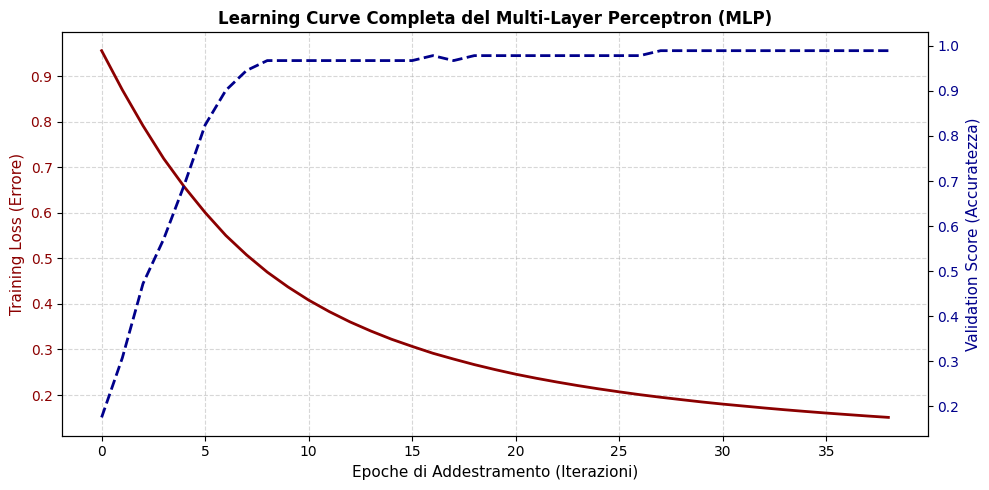

In [50]:
mlp_grafico.fit(X_train_scaled, y_train)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'darkred'
ax1.set_xlabel('Epoche di Addestramento (Iterazioni)', fontsize=11)
ax1.set_ylabel('Training Loss (Errore)', color=color, fontsize=11)
ax1.plot(mlp_grafico.loss_curve_, color=color, lw=2, label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
color = 'darkblue'
ax2.set_ylabel('Validation Score (Accuratezza)', color=color, fontsize=11)
ax2.plot(mlp_grafico.validation_scores_, color=color, lw=2, linestyle='--', label='Validation Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Learning Curve Completa del Multi-Layer Perceptron (MLP)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

Analisi della Curva del Multi-Layer Perceptron (MLP)

Il grafico soprastante mostra l'andamento della Funzione di Perdita (Loss) del modello MLP lungo le epoche di addestramento e l'accuratezza sul set di validazione interna, fornendo informazioni importanti sulla qualità dell'apprendimento.
Si può notare che la curva rossa dell'addestramento (Training Loss) scende in modo estremamente rapido nelle prime 25 epoche, dimostrando che il modello riduce drasticamente i propri errori fin dalle prime iterazioni. Parallelamente, la curva blu tratteggiata, che monitora l'Accuracy sul Validation Set, aumenta velocemente e si stabilizza poco sotto il valore di 0.97 (97%). Il fatto che l'accuratezza di validazione rimanga alta e costante senza subire flessioni mentre la loss scende, permette di escludere fenomeni di overfitting, confermando la stabilità e la bontà dell'addestramento. 

Stampiamo il Report di Classificazione

In [51]:
print("--- PERFORMANCE Multi-Layer Perceptrons OTTIMIZZATA (TEST SET) ---")
print(classification_report(y_test, y_pred_mlp))

--- PERFORMANCE Multi-Layer Perceptrons OTTIMIZZATA (TEST SET) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



Nonostante la curva di apprendimento sia eccellente, i risultati ottenuti sul Test Set finale mostrano che, con un dataset di dimensioni contenute come quello utilizzato in questo progetto (455 record nel Train Set), il Multi-Layer Perceptron (MLP) non riesce a superare le prestazioni degli altri modelli.
Infatti possiamo notare che il modello non è riuscito a fare meglio, la recall è scesa al 90% e di conseguenza anche F1-score è sceso al 95%, probabilmente perchè il dataset è di piccole dimensioni.
Questo non significa che l'MLP sia un algoritmo poco efficace. Al contrario, le reti neurali artificiali esprimono il loro massimo potenziale soprattutto quando possono apprendere da grandi quantità di dati.

# 7. Valutazione e confronto dei risultati



Metriche di valutazione

Per valutare le prestazioni dei modelli abbiamo ricercato i migliori parametri con la GridSearchCV e utilizzato il Classification Report di Scikit-Learn, che restituisce le principali metriche di classificazione: Precision, Recall, F1-Score e Accuracy.

In un problema di diagnosi medica la metrica più importante è la Recall, poiché misura la capacità del modello di identificare correttamente i tumori maligni. Un valore elevato di Recall permette infatti di ridurre il numero di falsi negativi, cioè pazienti realmente malati classificati erroneamente come sani.

Poiché il Classification Report è già stato stampato durante l'addestramento di ciascun modello, non abbiamo ritenuto opportuno ricalcolarlo anche in in questa sezione.

Grafici di confronto

Per completare il confronto tra i modelli rappresentiamo graficamente le rispettive prestazioni utilizzando l'F1-Score, che sintetizza Precision e Recall in un'unica metrica.


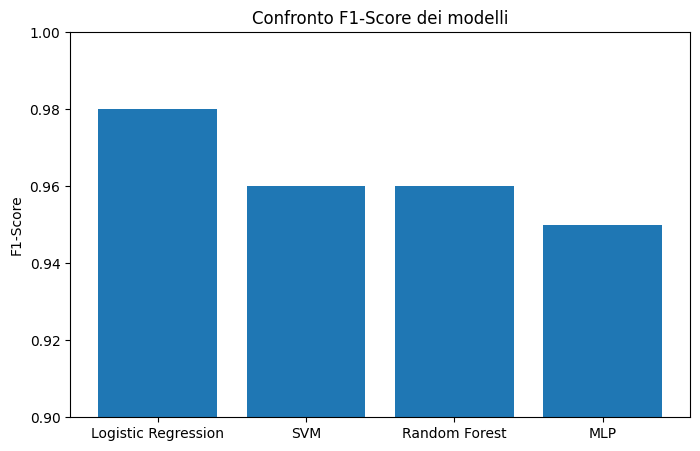

In [54]:
modelli = ['Logistic Regression', 'SVM', 'Random Forest', 'MLP']
f1 = [0.98, 0.96, 0.96, 0.95]

plt.figure(figsize=(8,5))
plt.bar(modelli, f1)
plt.title('Confronto F1-Score dei modelli')
plt.ylabel('F1-Score')
plt.ylim(0.90,1.00)
plt.show()

Osserviamo il grafico

Dal grafico si nota che tutti i modelli raggiungono prestazioni molto elevate. Tuttavia la Logistic Regression ottiene il valore di F1-Score più alto, dimostrando il miglior equilibrio tra Precision e Recall.

Confrontiamo le Confusion Matrix dei modelli

Per confrontare nel dettaglio le prestazioni dei quattro algoritmi, rappresentiamo la Confusion Matrix di ciascun modello. In questo modo possiamo osservare il numero di classificazioni corrette e gli errori commessi dai vari modelli.

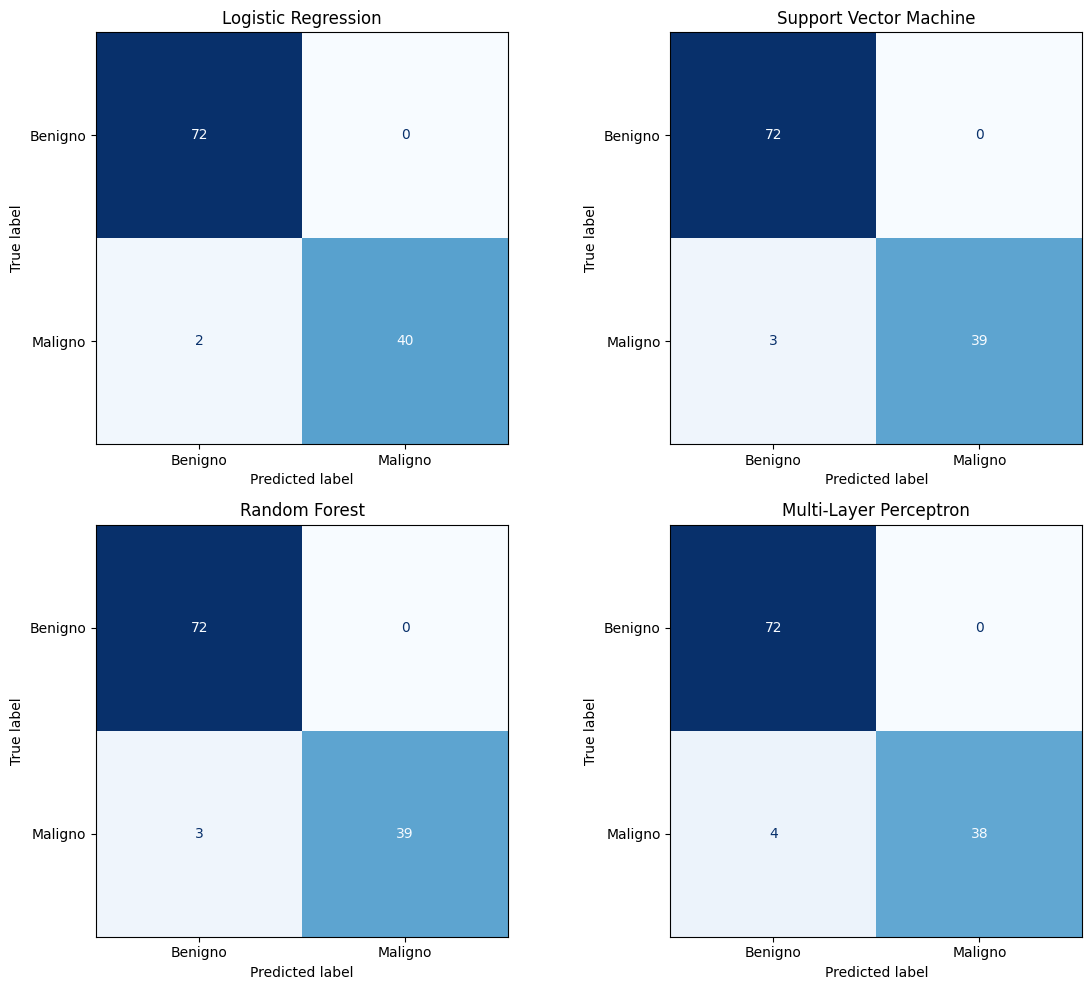

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Creiamo una figura con 4 grafici
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

modelli = [
    ("Logistic Regression", y_pred_lr),
    ("Support Vector Machine", y_pred_svm),
    ("Random Forest", y_pred_rf),
    ("Multi-Layer Perceptron", y_pred_mlp)
]

for ax, (nome, predizioni) in zip(axes.ravel(), modelli):

    cm = confusion_matrix(y_test, predizioni)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benigno", "Maligno"]
    )

    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nome)

plt.tight_layout()
plt.show()

Osserviamo le Confusion Matrix

Le quattro matrici confermano quanto emerso dalle metriche di valutazione. Tutti i modelli classificano correttamente la maggior parte dei pazienti, evidenziando un numero molto ridotto di errori.

In particolare, la Logistic Regression mostra la matrice più pulita, con il maggior numero di classificazioni corrette sulla diagonale principale e un numero minimo di errori. Il Multi-Layer Perceptron presenta qualche errore in più nell'identificazione dei casi maligni(dovuto ad un dataset ridotto).

Poiché in ambito medico i falsi negativi rappresentano l'errore più critico, l'analisi delle Confusion Matrix conferma la scelta della Logistic Regression come modello più affidabile per questo problema.

Confronto tra modelli

I quattro algoritmi analizzati hanno ottenuto risultati molto simili, tutti superiori al 95% di Accuratezza.

La Logistic Regression ha dimostrato che le due classi risultano quasi linearmente separabili.

La Support Vector Machine, utilizzando un kernel non lineare, ha confermato le prestazioni della Logistic Regression, mostrando un'elevata capacità di generalizzazione.

La Random Forest nonostante sia un ottimo modello per questo tipo di dataset, non è influenzato dalla forte correlazione che hanno alcune caratteristiche, non è risultato il migliore.

Il Multi-Layer Perceptron ha fornito ottimi risultati ma, a causa della limitata quantità di dati disponibili, non è riuscito a superare gli altri.

Interpretazione critica dei risultati

L'analisi delle prestazioni mostra come tutti i modelli siano in grado di distinguere efficacemente tumori benigni e maligni.

La fase di EDA aveva già evidenziato una buona separazione tra le classi attraverso le caratteristiche geometriche delle cellule, risultato poi confermato dai modelli di Machine Learning.

La Logistic Regression ha dimostrato di essere l' algoritmo più adatto a questo dataset, riuscendo a combinare elevata Precision, Recall e robustezza nei confronti di outlier e variabili correlate.

# 8. Conclusioni finali

Problema affrontato

L'obiettivo del progetto era sviluppare un sistema di classificazione in grado di distinguere tumori benigni e maligni utilizzando le caratteristiche geometriche dei nuclei cellulari presenti nel dataset Breast Cancer Wisconsin.

Metodo seguito

Il progetto è iniziato con una fase di analisi esplorativa dei dati (EDA), durante la quale sono stati analizzati la distribuzione delle classi, le caratteristiche principali del dataset e le correlazioni tra le variabili.

Successivamente sono state eliminate le colonne non necessarie, convertita la variabile target in formato numerico, identificati gli eventuali outlier mediante Z-Score e normalizzate le caratteristiche tramite StandardScaler.

Infine sono stati addestrati quattro differenti modelli di Machine Learning: Logistic Regression, Support Vector Machine, Random Forest e Multi-Layer Perceptron.

Risultati principali

Tutti i modelli hanno raggiunto prestazioni abbastanza elevate, dimostrando che le caratteristiche geometriche delle cellule consentono di distinguere efficacemente tumori benigni e maligni.

Conclusioni più importanti

L'analisi ha confermato quantitativamente quanto osservato in ambito clinico: le cellule maligne tendono ad avere dimensioni maggiori, una concavità più marcata e forme più irregolari rispetto alle cellule benigne.

I risultati ottenuti dimostrano inoltre che tecniche di Machine Learning possono rappresentare un valido supporto alla diagnosi medica, contribuendo a ridurre il numero di errori diagnostici e, in particolare, dei falsi negativi.

Eventuali limiti del lavoro svolto

Il principale limite del progetto è rappresentato dalla dimensione relativamente ridotta del dataset, costituito da poco più di cinquecento osservazioni, riscontrato soprattutto sul modello il Multi-Layer Perceptron
